##### 常數

In [1]:
VIDEO = "../../../../resources/video/normal/20240531/ex4.mp4"  # 影片路徑
MODEL = "./models/BlazePose/pose_landmarker_full.task"  # 模型路徑

OUT_PATH = "./output_video/output4.mp4"  # 影片輸出路徑

#### 套件

In [2]:
from pathlib import Path
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import (
    VisionTaskRunningMode,
)
from mediapipe.tasks.python.vision.pose_landmarker import (
    PoseLandmarker,
    PoseLandmarkerOptions,
)

In [3]:
from mpl_toolkits.mplot3d.axes3d import Axes, Axes3D
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

In [4]:
from src.mediapipe_lib.base import PoseResult, ResultAnalyzer, LhcPoseListAnalyzer
from src.calculate import get_true_rate_in_bool_list
from src.draw_template import (
    draw_debug_in_img,
    draw_kpt_position_in_img,
    get_bones_plot_axes,
    get_staggered_angle_axes,
    get_a_hand_to_gravity_axes,
    get_hand_center_to_gravity_axes,
    get_hand_to_gravity_info_axes,
)
from src.utils.plot_painter import (
    set_data_range,
    set_plot_labels,
    plot_to_opencv_img,
    draw_bool_list_line_chart,
    draw_pose_result_line_chart,
    draw_frequency_list_bar_chart,
    draw_execution_rate_bar_chart,
)

#### 忽略警告

In [5]:
import warnings

warnings.filterwarnings("ignore")

#### 函式

##### 設定圖表座標資訊

In [6]:
def set_axes_info(is_3d: bool, ax: Axes | Axes3D) -> Axes | Axes3D:
    """設定圖表座標資訊

    Args:
        is_3d (bool): 是否為 3D 姿勢
        ax (Axes | Axes3D): 圖表座標

    Returns:
        Axes | Axes3D: 圖表座標
    """

    # 設定圖表座標資訊
    if not is_3d:
        set_plot_labels("x", "y", ax=ax)  # 設定標籤
        set_data_range([0, 1], [1, 0], ax=ax)  # 設定資料範圍
    else:
        set_plot_labels("x", "z", "y", ax)  # 設定標籤
        set_data_range([-1, 1], [-1, 1], [0, 2], ax)  # 設定資料範圍

    return ax

##### 繪製分析結果圖表

In [7]:
def draw_result_plot(
    result: PoseLandmarkerResult,
    figsize: tuple[float, float] = (6.4, 4.8),
    is_3d: bool = False,
) -> cv2.typing.MatLike:
    """繪製分析結果圖表

    Args:
        result (PoseLandmarkerResult): 姿勢結果
        figsize (tuple[float, float], optional): 圖表大小. Defaults to (6.4, 4.8).
        is_3d (bool, optional): 是否為 3D 姿勢. Defaults to False.

    Returns:
        cv2.typing.MatLike: 分析結果圖片
    """
    # 建立分析器
    analyzer = ResultAnalyzer(PoseResult(result))

    # 建立圖表
    fig = plt.figure(figsize=figsize)
    ax: Axes3D = fig.add_subplot(projection="3d")

    # 設定圖表座標資訊
    set_axes_info(is_3d, ax)

    # 繪製表格
    if len(result.pose_world_landmarks) > 0:

        dist_l = analyzer.get_a_hand_to_gravity_dist(True, is_3d)
        dist_r = analyzer.get_a_hand_to_gravity_dist(False, is_3d)
        dist_c = analyzer.get_two_hands_center_to_gravity_dist(is_3d)

        left_arm = np.linalg.norm(
            np.array(analyzer.pose_result.get_kpt_pos_by_name("left_wrist", is_3d))
            - analyzer.pose_result.get_kpt_pos_by_name("left_elbow", is_3d)
        ) + np.linalg.norm(
            np.array(analyzer.pose_result.get_kpt_pos_by_name("left_shoulder", is_3d))
            - analyzer.pose_result.get_kpt_pos_by_name("left_elbow", is_3d)
        )

        right_arm = np.linalg.norm(
            np.array(analyzer.pose_result.get_kpt_pos_by_name("right_wrist", is_3d))
            - analyzer.pose_result.get_kpt_pos_by_name("right_elbow", is_3d)
        ) + np.linalg.norm(
            np.array(analyzer.pose_result.get_kpt_pos_by_name("right_shoulder", is_3d))
            - analyzer.pose_result.get_kpt_pos_by_name("right_elbow", is_3d)
        )

        ax.set_title(
            f"left: {dist_l:.2f}, right: {dist_r:.2f}, center: {dist_c:.2f}\n"
            + f"left arm: {left_arm:.2f}, right arm: {right_arm:.2f}\n"
            + f"dist_l: left_arm = {(dist_l / left_arm):.2f}: 1, dist_r: right_arm: : {(dist_r / right_arm):.2f}: 1"
        )

        get_bones_plot_axes(result, is_3d=is_3d, ax=ax)  # 繪製骨架
        get_hand_to_gravity_info_axes(result, is_3d, ax)  # 繪製手或重心遠離身體的資訊
        ax.legend()
    else:
        ax.set_title("NO DATA")

    # 將圖表轉換成圖片格式
    rgb = cv2.cvtColor(plot_to_opencv_img(fig), cv2.COLOR_RGBA2RGB)

    plt.close(fig)  # 關閉圖表

    return rgb

#### 開始測試

In [8]:
# 模型設定
options = PoseLandmarkerOptions(
    base_options=BaseOptions(MODEL), running_mode=VisionTaskRunningMode.VIDEO
)

# 輸出路徑
out_path = Path(OUT_PATH)
# 建立放置輸出檔案的資料夾
if not out_path.parent.exists():
    out_path.parent.mkdir(parents=True)  

is_3d = True  # 使用 3D 模型

# 影片輸出
zoom_ratio = 0.5  # 影片縮放倍率
fourcc = cv2.VideoWriter.fourcc(*"mp4v")  # fourcc 碼
fps = 30  # 幀率

In [9]:
cap = cv2.VideoCapture(VIDEO)  # 取得影片資訊
lhc_analyzer = LhcPoseListAnalyzer()  # LHC 姿勢分析器

# 影片大小
cap_size = np.array(
    [
        int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    ]
)
### 縮放原始影片大小
cap_size = (cap_size * zoom_ratio).astype(np.uint)
# 表格大小
plot_size = np.array([cap_size[0] * 2, cap_size[1]])
# 影片輸出寬高
out_width = cap_size[0] + plot_size[0]
out_height = cap_size[1]

# 建立模型物件
landmarker = PoseLandmarker.create_from_options(options)

# 影片輸出物件
video_out = cv2.VideoWriter(str(out_path), fourcc, fps, (out_width, out_height))

# 預設輸出影像幀
default_frame = np.zeros((out_height, out_width, 3))

# 進行串流
while cap.isOpened():

    # 抓取影像
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # 取得並儲存分析結果
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = landmarker.detect_for_video(mp_img, int(cap.get(cv2.CAP_PROP_POS_MSEC)))
    lhc_analyzer += [result]

    ### 縮放原始影片大小
    resized_frame = cv2.resize(frame, cap_size)

    # 繪製圖片關鍵點和偵錯資訊
    img = draw_kpt_position_in_img(result, resized_frame)
    img = draw_debug_in_img(result, img, is_3d)

    # 繪製分析圖表
    plot = draw_result_plot(result, plot_size / 100, is_3d)

    # 組合圖片
    out_frame: cv2.typing.MatLike = np.concatenate((img, plot), axis=1)

    # 儲存影片幀
    video_out.write(out_frame)

    # 顯示 OpenCV 視窗畫面
    # cv2.imshow("debug", out_frame)
    # if cv2.waitKey(1) == ord("q"):
    #     break

# cv2.destroyAllWindows()
cap.release()
video_out.release()
landmarker.close()
print("Finish")

Can't receive frame (stream end?). Exiting ...
Finish


#### 驗證結果

In [10]:
is_3d = True

# 額外加分資訊
trunk_is_twisted_list = lhc_analyzer.get_trunk_is_twisted_list(is_3d)
hands_at_a_distance_list = lhc_analyzer.get_hands_at_a_distance_list(is_3d)
arms_raised_list = lhc_analyzer.get_arms_raised_list(is_3d)
hands_above_shoulder_list = lhc_analyzer.get_hands_above_shoulder_list(is_3d)
# 額外加分結果
trunk_is_twisted_result = str(
    lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name
)
hands_at_a_distance_result = str(
    lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name
)
arms_raised_result = str(lhc_analyzer.get_frequency_of_arms_raised(is_3d).name)
hands_above_shoulder_result = str(
    lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name
)
# 額外加分頻率
trunk_is_twisted_frequency = trunk_is_twisted_list.count(True) / len(trunk_is_twisted_list)
hands_at_a_distance_frequency = hands_at_a_distance_list.count(True) / len(hands_at_a_distance_list)
arms_raised_frequency = arms_raised_list.count(True) / len(arms_raised_list)
hands_above_shoulder_frequency = hands_above_shoulder_list.count(True) / len(hands_above_shoulder_list)

# 標籤列表
label_lst = lhc_analyzer.get_lhc_label_list(is_3d)
filter_labels_a = LhcPoseListAnalyzer.filter_label_list_in_fun_a(label_lst)
filter_labels_b = LhcPoseListAnalyzer.filter_label_list_in_fun_b(label_lst)

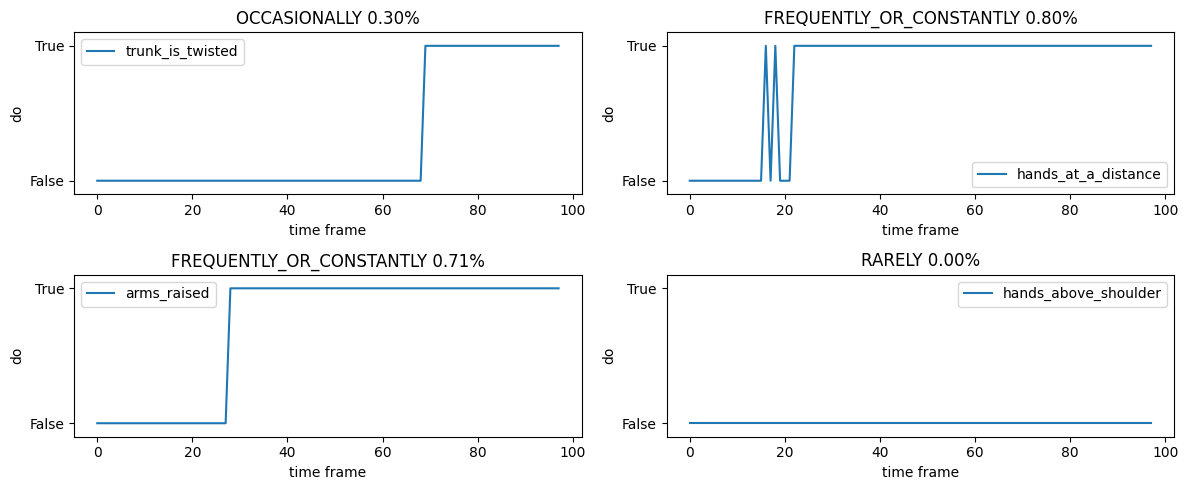

In [11]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(221)
ax1.set_title(f"{trunk_is_twisted_result} {trunk_is_twisted_frequency:.2f}%")
draw_bool_list_line_chart(trunk_is_twisted_list, "trunk_is_twisted", ax1)
ax1.legend()

ax2 = fig.add_subplot(222)
ax2.set_title(f"{hands_at_a_distance_result} {hands_at_a_distance_frequency:.2f}%")
draw_bool_list_line_chart(hands_at_a_distance_list, "hands_at_a_distance", ax2)
ax2.legend()

ax3 = fig.add_subplot(223)
ax3.set_title(f"{arms_raised_result} {arms_raised_frequency:.2f}%")
draw_bool_list_line_chart(arms_raised_list, "arms_raised", ax3)
ax3.legend()

ax4 = fig.add_subplot(224)
ax4.set_title(f"{hands_above_shoulder_result} {hands_above_shoulder_frequency:.2f}%")
draw_bool_list_line_chart(hands_above_shoulder_list, "hands_above_shoulder", ax4)
ax4.legend()

fig.tight_layout()

plt.show()

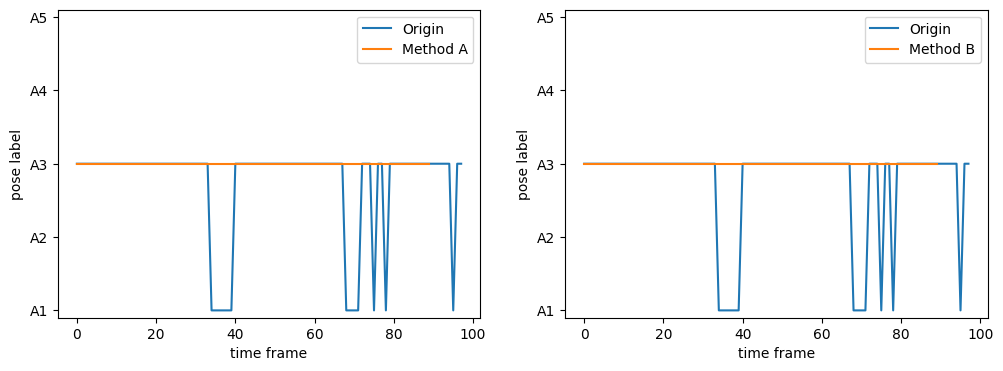

In [12]:
fig = plt.figure(figsize=(12, 4))

ax0 = fig.add_subplot(121)
draw_pose_result_line_chart(label_lst, "Origin", ax0)
draw_pose_result_line_chart(filter_labels_a, "Method A", ax0)
ax0.legend()

ax1 = fig.add_subplot(122)
draw_pose_result_line_chart(label_lst, "Origin", ax1)
draw_pose_result_line_chart(filter_labels_a, "Method B", ax1)
ax1.legend()

plt.show(fig)